In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

In [2]:
def extract_publisher_data(row):
    if row.get('publisher_metadata'):
        pm = row['publisher_metadata']
        return pd.Series({
            'publisher_date': pd.to_datetime(
                f"{pm['published_year']}-{pm['published_month']}-{pm['published_day']}"
            ),
            'is_preprint': pm.get('is_preprint')
        })
    return pd.Series({'publisher_date': None, 'is_preprint': None})

**API call to get all Public Collections**

In [3]:
api_url_base = 'https://api.cellxgene.cziscience.com'
path_segment = '/collections'
url = f'{api_url_base}/curation/v1{path_segment}'
r = requests.get(url)
collections = r.json()

df = pd.DataFrame(collections)[['contact_name','published_at','publisher_metadata']]
df['published_at'] = pd.to_datetime(df['published_at']).dt.tz_localize(None)
df[['publisher_date', 'is_preprint']] = df.apply(extract_publisher_data, axis=1)
df['date_diff_days'] = (df['published_at'] - df['publisher_date']).dt.days

contact_vc = df['contact_name'].value_counts().to_frame()

print(f'{len(df)} total submissions')
print(f'{len(contact_vc)} total contributors')

363 total submissions
274 total contributors


**Extract repeat contributor stats based on Collection contacts**

In [4]:
multicontrib = contact_vc[contact_vc['count'] > 1]
print(f'{len(multicontrib)} contributors have submitted multiple times')
print(f'{multicontrib["count"].sum()} submissions have come from repeat contributors')

46 contributors have submitted multiple times
135 submissions have come from repeat contributors


**For Collections with publications, get the difference between publication date and Collection release date**

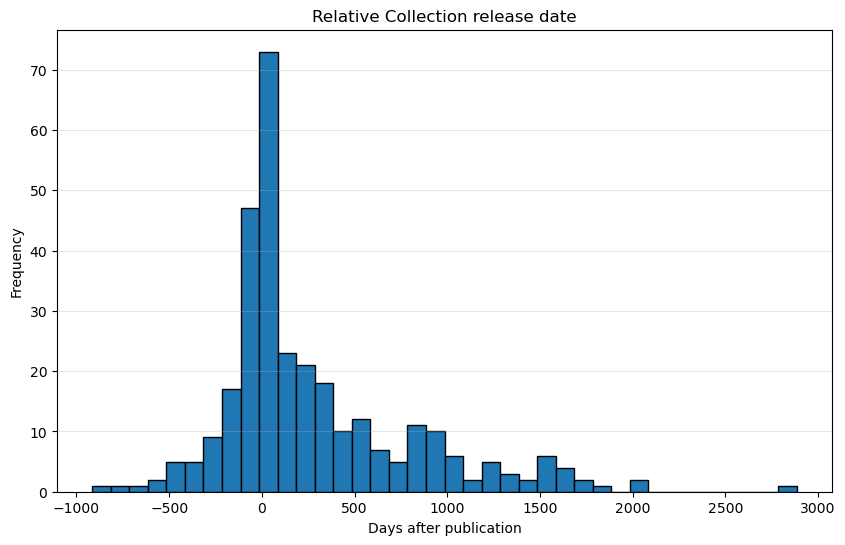

In [5]:
non_preprints = df[df['is_preprint'] == False]

bins = np.arange(non_preprints['date_diff_days'].min(), non_preprints['date_diff_days'].max() + 100, 100)

plt.figure(figsize=(10, 6))
plt.hist(non_preprints['date_diff_days'].dropna(), bins=bins, edgecolor='black')
plt.xlabel('Days after publication')
plt.ylabel('Frequency')
plt.title('Relative Collection release date')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Evaluate how many Collections were released more than `x` days after the publication date**

In [6]:
x = 200

count = (non_preprints['date_diff_days'] > x).sum()
per = (count / len(df)) * 100
print(f'Released at least {x} days after manuscript publication date:')
print(f'{count} collections')
print(f'{round(per,1)}% of all collections')

Released at least 200 days after manuscript publication date:
126 collections
34.7% of all collections
